# DR Criterion Study
### ttH(bb) dilepton — mass reco combination selection analysis
Compares max_weight-only selection vs DR-criterion selection across all 4 ranks.

In [11]:
from coffea.util import load
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import hist
import warnings
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
COFFEA_FILE = '/eos/home-i04/p/piosifid/PocketCoffea/ANN_newCoffea/DATA_MassReco/test_all_data/output_all.coffea'
DATA_DATASETS = ['DATA_Muon__rmOverlap', 'DATA_MuonEG__rmOverlap', 'DATA_EGamma__rmOverlap']
CATEGORY    = 'baseline_all_atleast4bjets'

out = load(COFFEA_FILE)
print('Top-level keys:', list(out.keys())[:10], '...')

variables = out['variables']
all_vars = list(variables.keys())
print(f'Total histograms: {len(all_vars)}')
mass_vars = [v for v in all_vars if any(k in v.lower() for k in 
             ['higgs_mass', 'massreco', 'max_weight', 'rank_used', 'dr_chosen', 'dr_rank'])]
print('\nMass/DR related:')
for v in sorted(mass_vars):
    print(' ', v)

Top-level keys: ['sum_genweights', 'sum_signOf_genweights', 'sumw', 'sumw2', 'cutflow', 'variables', 'columns', 'processing_metadata', 'datasets_metadata'] ...
Total histograms: 106

Mass/DR related:
  Massreco_chosen_pair_higgs_mass
  Massreco_chosen_pair_higgs_mass_1
  Massreco_chosen_pair_higgs_mass_2
  Massreco_chosen_pair_higgs_mass_3
  Massreco_chosen_pair_higgs_mass_4
  Max_Weight
  Max_Weight_Higgs_Mass
  dr_chosen
  dr_chosen_from_fallback
  dr_chosen_from_rank1
  dr_chosen_from_rank2
  dr_chosen_from_rank3
  dr_chosen_from_rank4
  dr_rank1
  dr_rank1_rejected
  dr_rank2
  dr_rank2_rejected
  dr_rank3
  dr_rank3_rejected
  dr_rank4
  dr_rank4_rejected
  higgs_mass_chosen_binned
  higgs_mass_chosen_from_fallback
  higgs_mass_chosen_from_rank1
  higgs_mass_chosen_from_rank2
  higgs_mass_chosen_from_rank3
  higgs_mass_chosen_from_rank4
  higgs_mass_rank1
  higgs_mass_rank1_rejected
  higgs_mass_rank1_rejected_vs_rank2_selected
  higgs_mass_rank1_selected_vs_rejected
  higgs_mass_

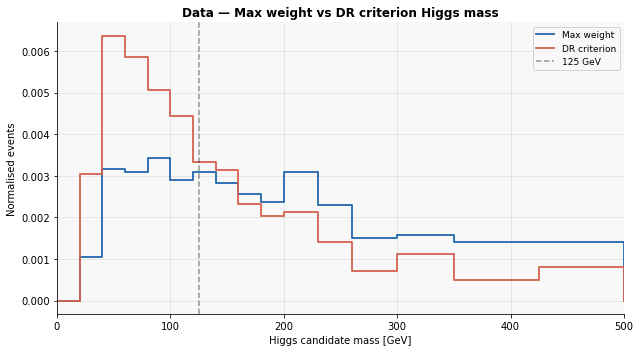

Data total events:
  Max_Weight_Higgs_Mass: 406
  Massreco_chosen_pair_higgs_mass_4: 418


In [12]:
def get_hist_data(out, var, category=CATEGORY):
    from hist import Hist
    variables = out['variables']
    if var not in variables:
        raise KeyError(f"'{var}' not in variables.")
    total = None
    for dataset in DATA_DATASETS:
        if dataset not in variables[var]:
            continue
        h = None
        for variation, obj in variables[var][dataset].items():
            if isinstance(obj, Hist):
                h = obj
                break
        if h is None:
            continue
        ax_names = [ax.name for ax in h.axes]
        if 'cat' in ax_names:
            h = h[{'cat': category}]
        if 'variation' in ax_names:
            h = h[{'variation': 'nominal'}]
        total = h if total is None else total + h
    if total is None:
        raise ValueError(f"No data found for {var}")
    return total.values(), total.axes[0].edges

# Plot: Max weight vs DR criterion — DATA
fig, ax = plt.subplots(figsize=(9, 5))

for var, color, label in [
    ('Max_Weight_Higgs_Mass',             COLORS['maxweight'], 'Max weight'),
    ('Massreco_chosen_pair_higgs_mass_4', COLORS['dr'],        'DR criterion'),
]:
    v, e = get_hist_data(out, var)
    norm = integral(v, e)
    ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
            where='post', color=color, label=label, linewidth=1.8)

ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 500)
ax.legend(fontsize=9)
ax.set_title('Data — Max weight vs DR criterion Higgs mass', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_data_mw_vs_dr.png', dpi=150)
plt.show()

print(f'Data total events:')
for var in ['Max_Weight_Higgs_Mass', 'Massreco_chosen_pair_higgs_mass_4']:
    v, e = get_hist_data(out, var)
    print(f'  {var}: {int(v.sum())}')

In [3]:
def get_hist(out, var, category=CATEGORY):
    """Return (values, edges) summing over all data datasets."""
    from hist import Hist
    variables = out['variables']
    if var not in variables:
        raise KeyError(f"'{var}' not in variables.")
    total = None
    for dataset in DATA_DATASETS:
        if dataset not in variables[var]:
            continue
        for variation, obj in variables[var][dataset].items():
            if isinstance(obj, Hist):
                h = obj
                break
        ax_names = [ax.name for ax in h.axes]
        if 'cat' in ax_names:
            h = h[{'cat': category}]
        if 'variation' in ax_names:
            h = h[{'variation': 'nominal'}]
        if total is None:
            total = h
        else:
            total = total + h
    if total is None:
        raise ValueError(f"No data found for {var}")
    return total.values(), total.axes[0].edges

def centres(edges):
    return 0.5 * (edges[:-1] + edges[1:])

def integral(vals, edges):
    widths = np.diff(edges)
    return np.sum(vals * widths)

# ── style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        12,
})

COLORS = {
    'rank1': '#2166ac',
    'rank2': '#f4a582',
    'rank3': '#d6604d',
    'rank4': '#92c5de',
    'maxweight': '#2166ac',
    'dr':        '#d6604d',
    'truth':     '#4dac26',
}

print('Helpers loaded.')

Helpers loaded.


## Step 1 — Check available histograms

In [4]:
# Print all histogram names to verify what's in the file
all_vars = list(out.keys())
dr_vars  = [v for v in all_vars if any(k in v.lower() for k in
             ['rank', 'dr_', 'correct_match', 'maxweight', 'chosen', 'truth', 'pair_in', 'mass_reco_had'])]
print('DR-study related histograms found:')
for v in sorted(dr_vars):
    print(' ', v)

DR-study related histograms found:


## Group 1 — DR Criterion Activity
### Plot 1.1 — How often does each rank get used?

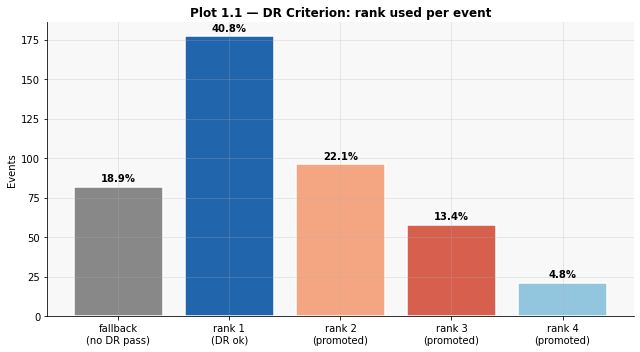

In [5]:
vals, edges = get_hist(out, 'rank_used')

# Skip bin 0 (no reco = None, always 0)
vals_plot   = vals[1:]
rank_labels = ['fallback\n(no DR pass)', 'rank 1\n(DR ok)',
               'rank 2\n(promoted)', 'rank 3\n(promoted)', 'rank 4\n(promoted)']
bar_colors  = ['#888888', COLORS['rank1'], COLORS['rank2'], COLORS['rank3'], COLORS['rank4']]

fig, ax = plt.subplots(figsize=(9, 5))
bars  = ax.bar(range(len(vals_plot)), vals_plot, color=bar_colors, edgecolor='white', linewidth=1.5)
total = vals_plot.sum()
for bar, v in zip(bars, vals_plot):
    pct = 100 * v / max(1, total)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(vals_plot)))
ax.set_xticklabels(rank_labels, fontsize=10)
ax.set_ylabel('Events')
ax.set_title('Plot 1.1 — DR Criterion: rank used per event', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_1_1_rank_used.png', dpi=150)
plt.show()

## Group 2 — Kinematics per rank
### Plot 2.1 — Higgs mass distributions per rank

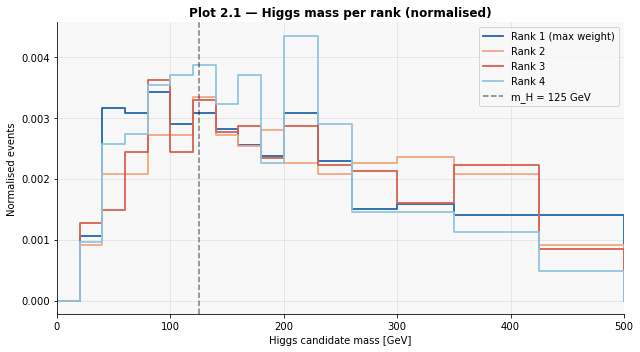

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for rank, color, label in [
    ('higgs_mass_rank1', COLORS['rank1'], 'Rank 1 (max weight)'),
    ('higgs_mass_rank2', COLORS['rank2'], 'Rank 2'),
    ('higgs_mass_rank3', COLORS['rank3'], 'Rank 3'),
    ('higgs_mass_rank4', COLORS['rank4'], 'Rank 4'),
]:
    try:
        v, e = get_hist(out, rank)
        norm = integral(v, e)
        #ax.step(np.append(e[:-1], e[-1]), np.append(v, 0),
        #where='post', color=color, label=label, linewidth=1.8)
        ax.step(np.append(e[:-1], e[-1]), np.append(v / max(1, norm), 0),
        where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {rank}: {ex}')

ax.axvline(125, color='black', linestyle='--', alpha=0.5, label='m_H = 125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 500)
ax.legend()
ax.set_title('Plot 2.1 — Higgs mass per rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_2_1_higgs_mass_per_rank.png', dpi=150)
plt.show()

### Plot 2.2 — DR distributions per rank

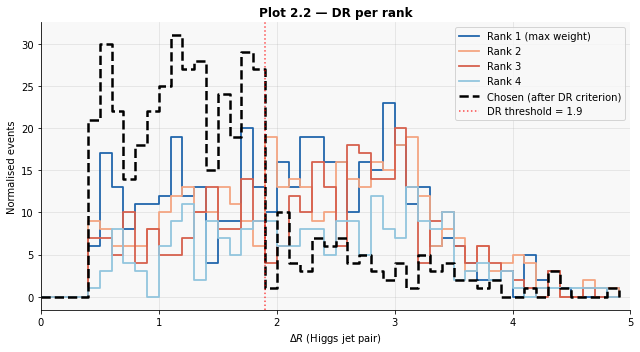

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for rank, color, label in [
    ('dr_rank1', COLORS['rank1'], 'Rank 1 (max weight)'),
    ('dr_rank2', COLORS['rank2'], 'Rank 2'),
    ('dr_rank3', COLORS['rank3'], 'Rank 3'),
    ('dr_rank4', COLORS['rank4'], 'Rank 4'),
    ('dr_chosen', 'black',        'Chosen (after DR criterion)'),
]:
    try:
        v, e = get_hist(out, rank)
        norm = integral(v, e)
        ls = '-' if rank != 'dr_chosen' else '--'
        lw = 1.8 if rank != 'dr_chosen' else 2.5
        ax.step(e[:-1], v , where='post', color=color,
                label=label, linewidth=lw, linestyle=ls)
    except Exception as ex:
        print(f'  Skipping {rank}: {ex}')

ax.axvline(1.9, color='red', linestyle=':', alpha=0.7, label='DR threshold = 1.9')
ax.set_xlabel(r'$\Delta R$ (Higgs jet pair)')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 5)
ax.legend()
ax.set_title('Plot 2.2 — DR per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_2_2_dr_per_rank.png', dpi=150)
plt.show()

## Group 3 — Truth matching per rank
### Plot 3.1 — correct_match distribution: max_weight vs DR criterion

  Skipping correct_match_maxweight: "'correct_match_maxweight' not in variables."
  Skipping correct_match_dr: "'correct_match_dr' not in variables."


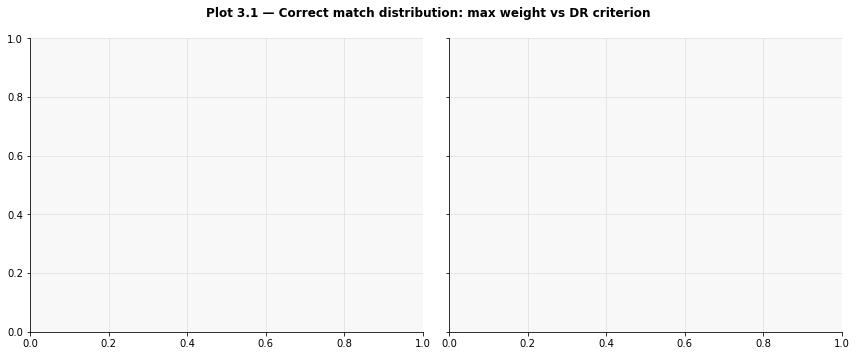

### Plot 3.2 — Promotion category breakdown
Derived from `rank_used`, `correct_match_maxweight`, `correct_match_dr`

Could not make plot 3.2: "'correct_match_maxweight' not in variables."


### Plot 3.3 — Higgs mass: correct vs wrong, for max_weight and DR criterion

  Skipping Massreco_chosen_pair_correct_higgs_mass: "'Massreco_chosen_pair_correct_higgs_mass' not in variables."
  Skipping Massreco_chosen_pair_wrong_higgs_mass: "'Massreco_chosen_pair_wrong_higgs_mass' not in variables."
  Skipping Massreco_maxweight_higgs_mass: "'Massreco_maxweight_higgs_mass' not in variables."
  Skipping Massreco_chosen_pair_wrong_higgs_mass: "'Massreco_chosen_pair_wrong_higgs_mass' not in variables."


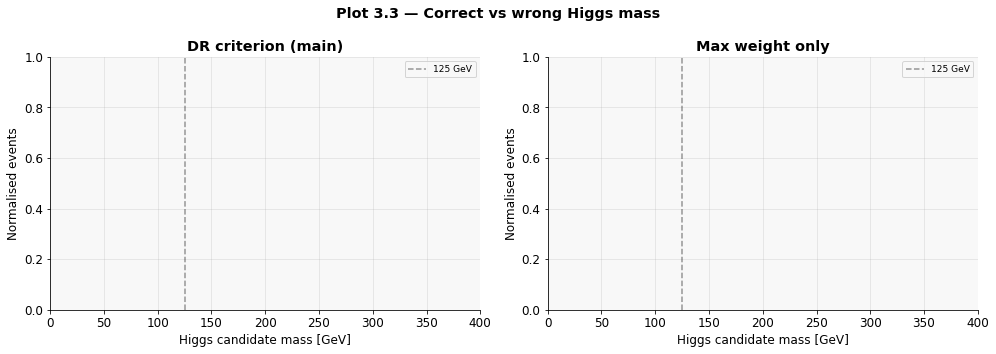

## Group 4 — Bottom line comparison
### Plot 4.1 — Overall Higgs mass: max_weight vs DR criterion

  Skipping massreco_maxweight_higgs_mass: "'massreco_maxweight_higgs_mass' not in variables."
  Skipping higgs_mass_chosen: "'higgs_mass_chosen' not in variables."


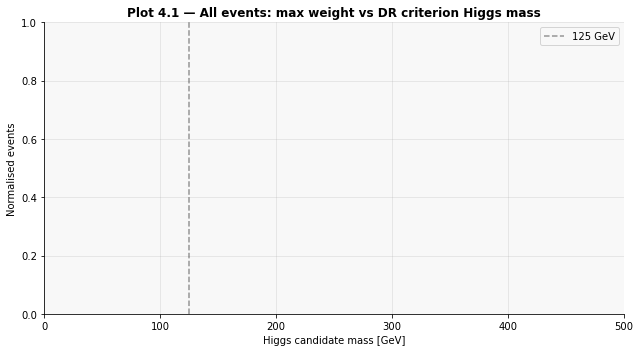

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for var, color, label in [
    ('massreco_maxweight_higgs_mass', COLORS['maxweight'], 'Max weight only'),
    ('higgs_mass_chosen',             COLORS['dr'],        'DR criterion'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')

ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 500)
ax.legend()
ax.set_title('Plot 4.1 — All events: max weight vs DR criterion Higgs mass', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_1_overall_mass_comparison.png', dpi=150)
plt.show()

### Plot 4.2 — Correct match Higgs mass & Plot 4.2b — Wrong match Higgs mass

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 4.2 — correct match
ax = axes[0]
for var, color, label in [
    ('massreco_chosen_pair_correct_higgs_mass', COLORS['dr'],        'DR criterion — correct'),
    ('massreco_maxweight_higgs_mass',           COLORS['maxweight'], 'Max weight — all (proxy)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 4.2 — Correct match Higgs mass', fontweight='bold')

# Plot 4.2b — wrong match
ax = axes[1]
for var, color, label in [
    ('massreco_chosen_pair_wrong_higgs_mass',         COLORS['dr'],   'Neither jet correct'),
    ('massreco_chosen_pair_wrong_higgs_mass_1_jets',  '#f4a582',      'One jet correct'),
    ('massreco_chosen_pair_wrong_higgs_mass_2_jets',  '#d6604d',      'Both jets wrong (all)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post',
                color=color, label=label, linewidth=2)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 4.2b — Wrong match Higgs mass breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_4_2_correct_wrong_mass.png', dpi=150)
plt.show()

### Plot 4.3 — Efficiency: correct_match==2 rate, max_weight vs DR criterion

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

results = {}
for var, label in [
    ('correct_match_maxweight', 'Max weight only'),
    ('correct_match_dr',        'DR criterion'),
]:
    try:
        v, e = get_hist(out, var)
        # bins: 0=no reco, 1=neither, 2=one, 3=both correct
        total_with_reco = v[1:].sum()
        both_correct    = v[-1] if len(v) >= 4 else v[3]
        eff = both_correct / max(1, total_with_reco)
        results[label] = (eff, both_correct, total_with_reco)
    except Exception as ex:
        print(f'  Could not compute efficiency for {var}: {ex}')
        results[label] = (0, 0, 0)

labels = list(results.keys())
effs   = [results[l][0] for l in labels]
colors = [COLORS['maxweight'], COLORS['dr']]

bars = ax.bar(labels, effs, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
for bar, (label, (eff, n_correct, n_total)) in zip(bars, results.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{eff:.3f}\n({int(n_correct)}/{int(n_total)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Efficiency (correct_match == 2)')
ax.set_ylim(0, max(effs) * 1.3)
ax.set_title('Plot 4.3 — Mass reco efficiency: max weight vs DR criterion', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_3_efficiency_comparison.png', dpi=150)
plt.show()

print('\nSummary:')
for label, (eff, n_correct, n_total) in results.items():
    print(f'  {label}: {eff:.3f} ({int(n_correct)}/{int(n_total)})')
if len(results) == 2:
    effs_list = list(results.values())
    delta = effs_list[1][0] - effs_list[0][0]
    print(f'  Delta (DR - maxweight): {delta:+.3f} ({delta*100:+.1f}%)')

### Plot 4.4 — Truth Higgs mass vs reco Higgs mass
*(Requires 2D histogram — add to config and rerun if not available)*

In [ ]:
# Check if 2D histogram is available
try:
    h2d = out['truth_vs_reco_higgs_mass'][DATASET][CATEGORY]
    vals2d = h2d.values()
    ex = h2d.axes[0].edges
    ey = h2d.axes[1].edges

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, var2d, title in [
        (axes[0], 'truth_vs_reco_higgs_mass_maxweight', 'Max weight only'),
        (axes[1], 'truth_vs_reco_higgs_mass',           'DR criterion'),
    ]:
        try:
            h = out[var2d][DATASET][CATEGORY]
            im = ax.pcolormesh(h.axes[0].edges, h.axes[1].edges,
                               h.values().T, cmap='Blues')
            plt.colorbar(im, ax=ax, label='Events')
            ax.plot([0, 500], [0, 500], 'r--', alpha=0.5, label='truth = reco')
            ax.set_xlabel('Truth Higgs mass [GeV]')
            ax.set_ylabel('Reco Higgs mass [GeV]')
            ax.set_title(title, fontweight='bold')
            ax.legend()
        except Exception as ex:
            print(f'  {var2d} not available: {ex}')

    fig.suptitle('Plot 4.4 — Truth vs reco Higgs mass 2D', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_4_4_truth_vs_reco_2d.png', dpi=150)
    plt.show()

except:
    print('Plot 4.4: 2D histogram not in coffea file.')
    print('Add truth_vs_reco_higgs_mass to the config and rerun to enable this plot.')

## Group 5 — Selected vs Rejected per rank
### Plot 5.1 — Higgs mass: selected-from-rank overlaid

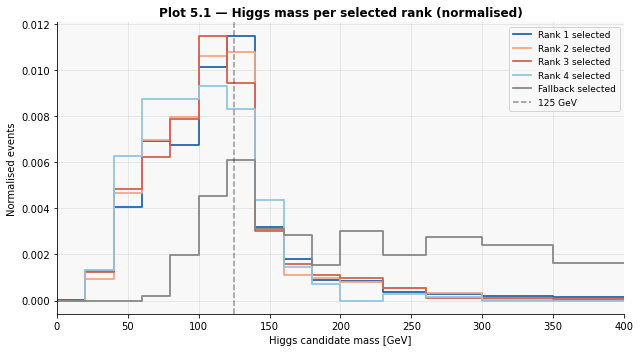

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
for var, color, label in [
    ('higgs_mass_chosen_from_rank1',   COLORS['rank1'], 'Rank 1 selected'),
    ('higgs_mass_chosen_from_rank2',   COLORS['rank2'], 'Rank 2 selected'),
    ('higgs_mass_chosen_from_rank3',   COLORS['rank3'], 'Rank 3 selected'),
    ('higgs_mass_chosen_from_rank4',   COLORS['rank4'], 'Rank 4 selected'),
    ('higgs_mass_chosen_from_fallback','#888888',       'Fallback selected'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 5.1 — Higgs mass per selected rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5_1_higgs_mass_selected_per_rank.png', dpi=150)
plt.show()

### Plot 5.2 — Higgs mass: rejected-from-rank overlaid

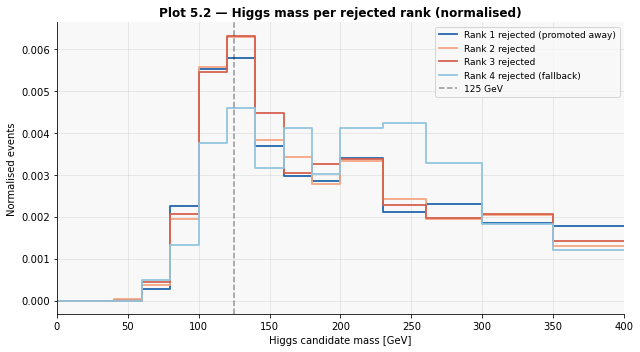

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
for var, color, label in [
    ('higgs_mass_rank1_rejected', COLORS['rank1'], 'Rank 1 rejected (promoted away)'),
    ('higgs_mass_rank2_rejected', COLORS['rank2'], 'Rank 2 rejected'),
    ('higgs_mass_rank3_rejected', COLORS['rank3'], 'Rank 3 rejected'),
    ('higgs_mass_rank4_rejected', COLORS['rank4'], 'Rank 4 rejected (fallback)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(e[:-1], v / max(1, norm), where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs candidate mass [GeV]')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 400)
ax.legend(fontsize=9)
ax.set_title('Plot 5.2 — Higgs mass per rejected rank (normalised)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5_2_higgs_mass_rejected_per_rank.png', dpi=150)
plt.show()

### Plot 5.3 — DR: selected vs rejected per rank (2x4 grid)

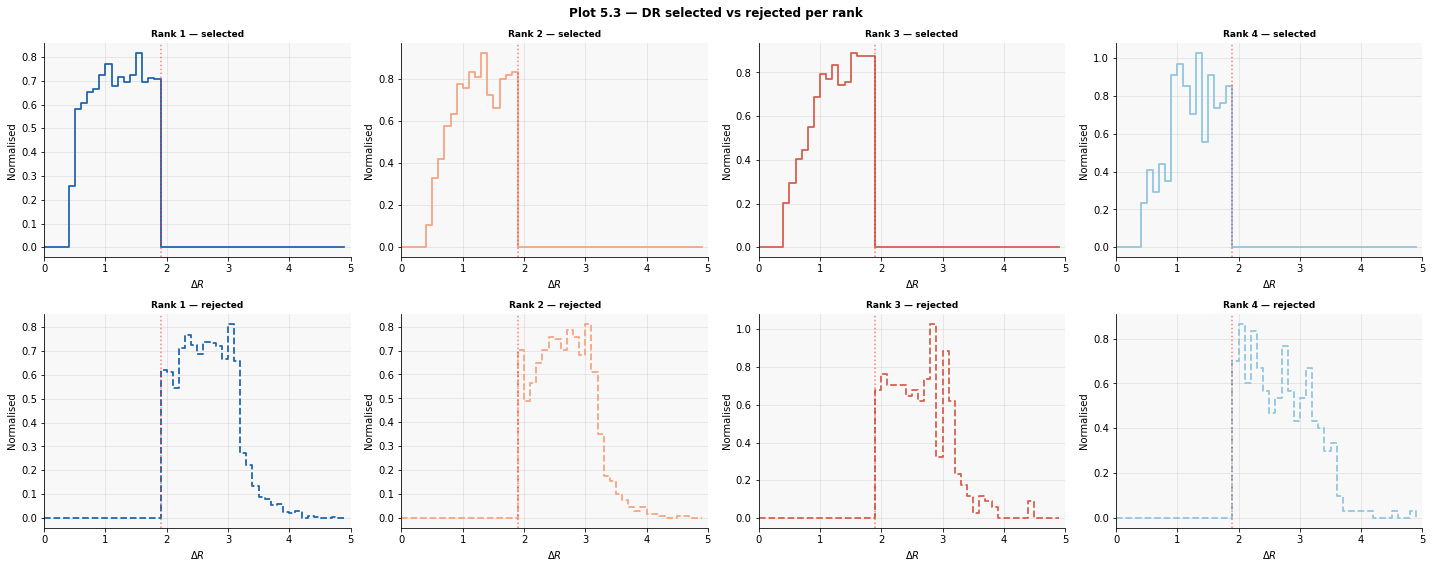

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
ranks = [
    ('dr_chosen_from_rank1',   'dr_rank1_rejected',   COLORS['rank1'], 'Rank 1'),
    ('dr_chosen_from_rank2',   'dr_rank2_rejected',   COLORS['rank2'], 'Rank 2'),
    ('dr_chosen_from_rank3',   'dr_rank3_rejected',   COLORS['rank3'], 'Rank 3'),
    ('dr_chosen_from_rank4',   'dr_rank4_rejected',   COLORS['rank4'], 'Rank 4'),
]
for col, (sel_var, rej_var, color, label) in enumerate(ranks):
    for row, (var, ls, title_sfx) in enumerate([
        (sel_var, '-',  'selected'),
        (rej_var, '--', 'rejected'),
    ]):
        ax = axes[row][col]
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(e[:-1], v / max(1, norm), where='post', color=color, linewidth=1.8, linestyle=ls)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
        ax.axvline(1.9, color='red', linestyle=':', alpha=0.5, label='DR=1.9')
        ax.set_xlabel(r'$\Delta R$')
        ax.set_ylabel('Normalised')
        ax.set_xlim(0, 5)
        ax.set_title(f'{label} — {title_sfx}', fontweight='bold', fontsize=9)
fig.suptitle('Plot 5.3 — DR selected vs rejected per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5_3_dr_selected_vs_rejected.png', dpi=150)
plt.show()

## Group 6 — 2D histograms
### Plot 6.1 — Mass vs mass rank transitions

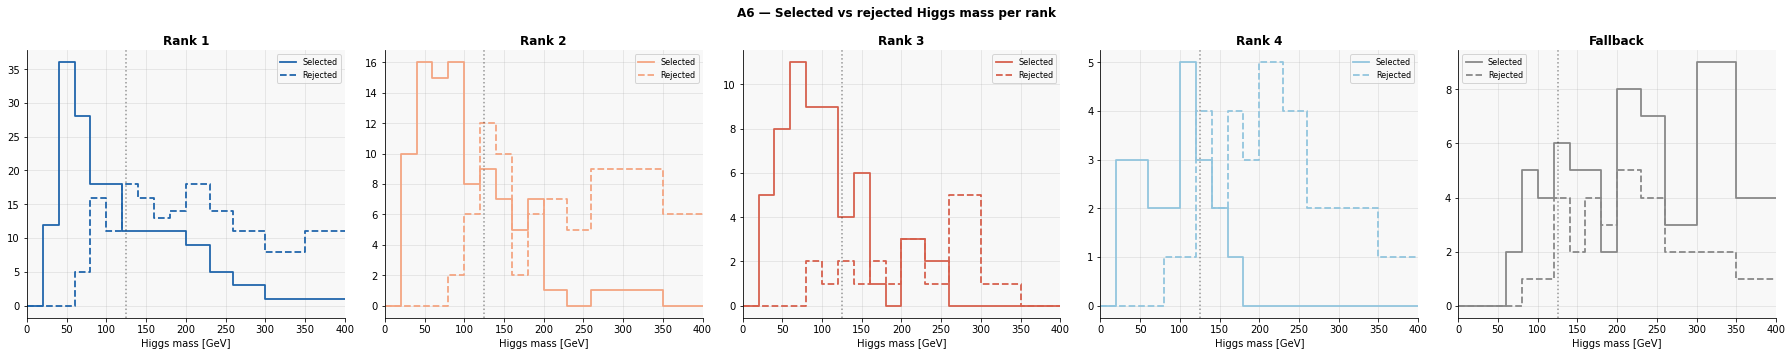

  Skipping Massreco_chosen_pair_correct_dr: "'Massreco_chosen_pair_correct_dr' not in variables."
  Skipping Massreco_chosen_pair_wrong_dr: "'Massreco_chosen_pair_wrong_dr' not in variables."


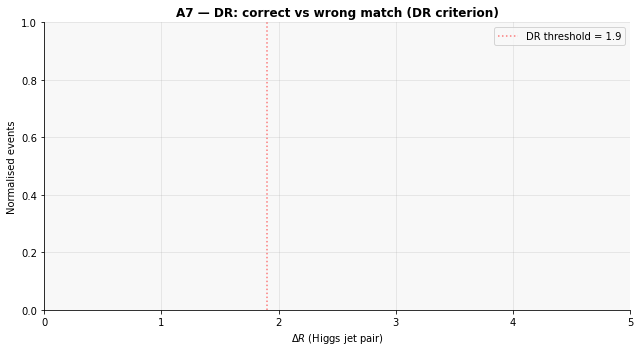

In [11]:
# A6 — Selected vs rejected mass per rank
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
rank_data = [
    ('higgs_mass_chosen_from_rank1',    'higgs_mass_rank1_rejected',   COLORS['rank1'], 'Rank 1'),
    ('higgs_mass_chosen_from_rank2',    'higgs_mass_rank2_rejected',   COLORS['rank2'], 'Rank 2'),
    ('higgs_mass_chosen_from_rank3',    'higgs_mass_rank3_rejected',   COLORS['rank3'], 'Rank 3'),
    ('higgs_mass_chosen_from_rank4',    'higgs_mass_rank4_rejected',   COLORS['rank4'], 'Rank 4'),
    ('higgs_mass_chosen_from_fallback', 'higgs_mass_rank4_rejected',   '#888888',       'Fallback'),
]
for ax, (sel_var, rej_var, color, label) in zip(axes, rank_data):
    for var, ls, lbl in [
        (sel_var, '-',  'Selected'),
        (rej_var, '--', 'Rejected'),
    ]:
        try:
            v, e = get_hist(out, var)
            norm = integral(v, e)
            ax.step(np.append(e[:-1], e[-1]), np.append(v , 0),
                    where='post', color=color, linestyle=ls, label=lbl, linewidth=1.8)
        except Exception as ex:
            print(f'  Skipping {var}: {ex}')
    ax.axvline(125, color='black', linestyle=':', alpha=0.4)
    ax.set_xlabel('Higgs mass [GeV]')
    ax.set_ylabel('')
    ax.set_xlim(0, 400)
    ax.legend(fontsize=8)
    ax.set_title(label, fontweight='bold')
fig.suptitle('A6 — Selected vs rejected Higgs mass per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A6_selected_vs_rejected_mass.png', dpi=150)
plt.show()

# A7 — DR correct vs wrong (DR criterion only for now)
fig, ax = plt.subplots(figsize=(9, 5))
for var, color, label in [
    ('Massreco_chosen_pair_correct_dr', COLORS['rank1'], 'Correct match (DR criterion)'),
    ('Massreco_chosen_pair_wrong_dr',   COLORS['rank3'], 'Wrong match (DR criterion)'),
]:
    try:
        v, e = get_hist(out, var)
        norm = integral(v, e)
        ax.step(np.append(e[:-1], e[-1]), np.append(v, 0),
                where='post', color=color, label=label, linewidth=1.8)
    except Exception as ex:
        print(f'  Skipping {var}: {ex}')
ax.axvline(1.9, color='red', linestyle=':', alpha=0.5, label='DR threshold = 1.9')
ax.set_xlabel(r'$\Delta R$ (Higgs jet pair)')
ax.set_ylabel('Normalised events')
ax.set_xlim(0, 5)
ax.legend()
ax.set_title('A7 — DR: correct vs wrong match (DR criterion)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_A7_dr_correct_vs_wrong.png', dpi=150)
plt.show()

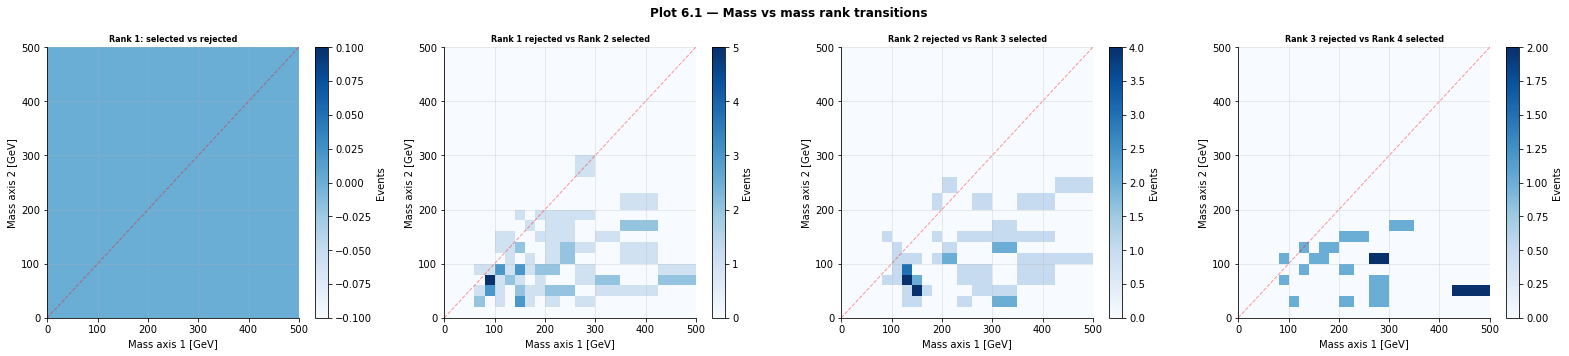

In [16]:
def get_hist2d(out, var, dataset=DATA_DATASETS, category=CATEGORY):
    """Return (values, edges) summing over all data datasets."""
    from hist import Hist
    variables = out['variables']
    if var not in variables:
        raise KeyError(f"'{var}' not in variables.")
    total = None
    for dataset in DATA_DATASETS:
        if dataset not in variables[var]:
            continue
        for variation, obj in variables[var][dataset].items():
            if isinstance(obj, Hist):
                h = obj
                break
        ax_names = [ax.name for ax in h.axes]
        if 'cat' in ax_names:
            h = h[{'cat': category}]
        if 'variation' in ax_names:
            h = h[{'variation': 'nominal'}]
        if total is None:
            total = h
        else:
            total = total + h
    if total is None:
        raise ValueError(f"No data found for {var}")
    return total.values(), total.axes[0].edges, total.axes[1].edges


transitions = [
    ('higgs_mass_rank1_selected_vs_rejected',   'Rank 1: selected vs rejected'),
    ('higgs_mass_rank1_rejected_vs_rank2_selected', 'Rank 1 rejected vs Rank 2 selected'),
    ('higgs_mass_rank2_rejected_vs_rank3_selected', 'Rank 2 rejected vs Rank 3 selected'),
    ('higgs_mass_rank3_rejected_vs_rank4_selected', 'Rank 3 rejected vs Rank 4 selected'),
]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (var, title) in zip(axes, transitions):
    try:
        vals, ex, ey = get_hist2d(out, var)
        im = ax.pcolormesh(ex, ey, vals.T, cmap='Blues')
        plt.colorbar(im, ax=ax, label='Events')
        ax.plot([0, 500], [0, 500], 'r--', alpha=0.4, linewidth=1)
        ax.set_xlabel('Mass axis 1 [GeV]')
        ax.set_ylabel('Mass axis 2 [GeV]')
        ax.set_title(title, fontweight='bold', fontsize=8)
    except Exception as ex_err:
        print(f'  Skipping {var}: {ex_err}')
fig.suptitle('Plot 6.1 — Mass vs mass rank transitions', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_6_1_mass_vs_mass_transitions.png', dpi=150)
plt.show()

### Plot 6.2 — DR vs mass per rank (selected and rejected)

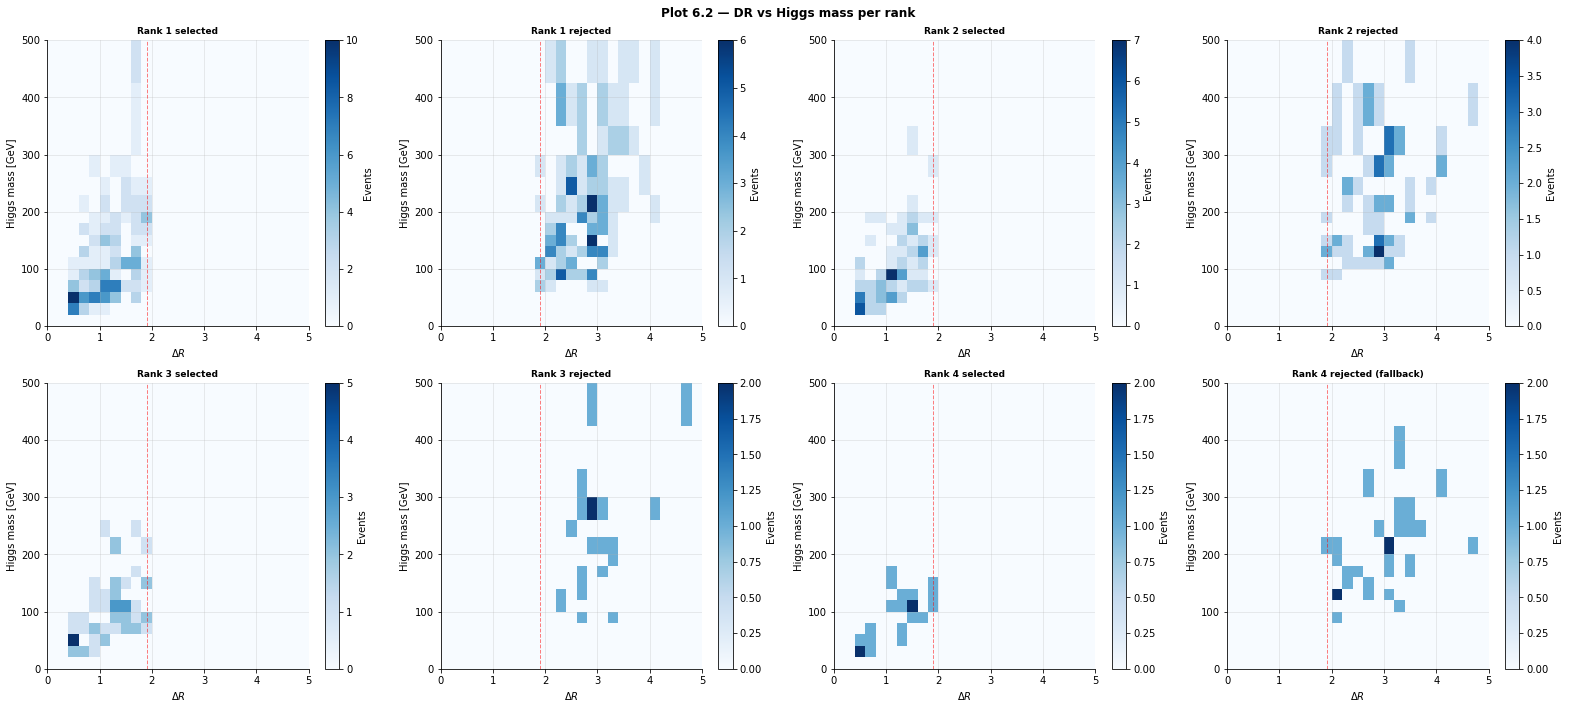

In [17]:
dr_mass_plots = [
    ('dr_vs_mass_rank1_selected', 'Rank 1 selected'),
    ('dr_vs_mass_rank1_rejected', 'Rank 1 rejected'),
    ('dr_vs_mass_rank2_selected', 'Rank 2 selected'),
    ('dr_vs_mass_rank2_rejected', 'Rank 2 rejected'),
    ('dr_vs_mass_rank3_selected', 'Rank 3 selected'),
    ('dr_vs_mass_rank3_rejected', 'Rank 3 rejected'),
    ('dr_vs_mass_rank4_selected', 'Rank 4 selected'),
    ('dr_vs_mass_rank4_rejected', 'Rank 4 rejected (fallback)'),
]
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()
for ax, (var, title) in zip(axes_flat, dr_mass_plots):
    try:
        vals, ex, ey = get_hist2d(out, var)
        im = ax.pcolormesh(ex, ey, vals.T, cmap='Blues')
        plt.colorbar(im, ax=ax, label='Events')
        ax.axvline(1.9, color='red', linestyle='--', alpha=0.5, linewidth=1, label='DR=1.9')
        ax.set_xlabel(r'$\Delta R$')
        ax.set_ylabel('Higgs mass [GeV]')
        ax.set_title(title, fontweight='bold', fontsize=9)
    except Exception as ex_err:
        print(f'  Skipping {var}: {ex_err}')
fig.suptitle('Plot 6.2 — DR vs Higgs mass per rank', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_6_2_dr_vs_mass_per_rank.png', dpi=150)
plt.show()

### Plot 6.3 — Truth vs reco Higgs mass 2D

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: All events — max weight vs DR criterion
ax = axes[0]
for var, color, label in [
    ('Max_Weight_Higgs_Mass',             COLORS['maxweight'], 'Max weight'),
    ('Massreco_chosen_pair_higgs_mass_4', COLORS['dr'],        'DR criterion'),
]:
    v, e = get_hist(out_mc, var)
    norm = integral(v, e)
    ax.step(np.append(e[:-1], e[-1]), np.append(v , 0),
            where='post', color=color, label=label, linewidth=1.8)
ax.axvline(125, color='black', linestyle='--', alpha=0.4, label='125 GeV')
ax.set_xlabel('Higgs mass [GeV]')
ax.set_ylabel('Events')
ax.set_xlim(0, 500)
ax.legend(fontsize=9)
ax.set_title('All events', fontweight='bold')


NameError: name 'plt' is not defined

## Summary

In [ ]:
print('All plots saved:')
import glob
for f in sorted(glob.glob('plot_*.png')):
    print(' ', f)